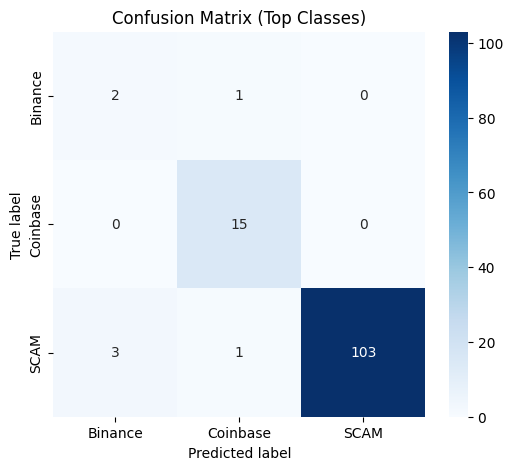

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

labels = ["Binance", "Coinbase", "SCAM"]

df = pd.read_csv("sslpa_eval_confusion_top15.csv", index_col=0)


df = df.loc[labels, labels]

plt.figure(figsize=(6, 5))
sns.heatmap(df, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Top Classes)")
plt.show()


2

In [3]:
df = pd.read_csv("sslpa_eval_node_details.csv")

coverage = df["reached"].mean()

accuracy_reached = df[df["reached"] == True]["correct"].mean()

print("Coverage:", coverage)
print("Accuracy (reached only):", accuracy_reached)

Coverage: 0.37537537537537535
Accuracy (reached only): 0.96


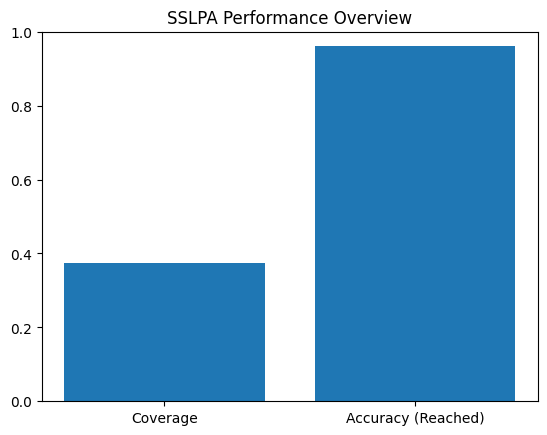

In [4]:
import matplotlib.pyplot as plt

values = [coverage, accuracy_reached]
labels = ["Coverage", "Accuracy (Reached)"]

plt.bar(labels, values)
plt.ylim(0, 1)
plt.title("SSLPA Performance Overview")
plt.show()

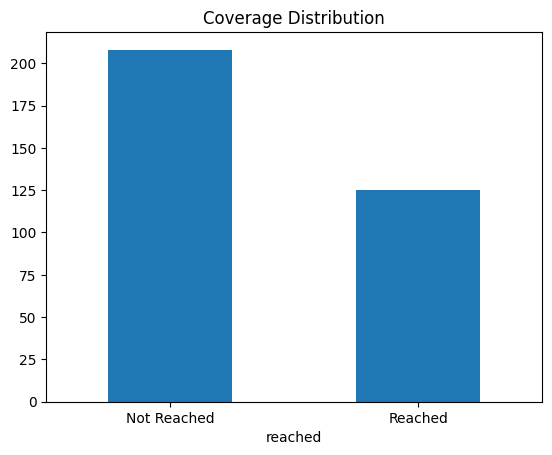

In [5]:
counts = df["reached"].value_counts()

counts.plot(kind="bar")
plt.xticks([0,1], ["Not Reached", "Reached"], rotation=0)
plt.title("Coverage Distribution")
plt.show()

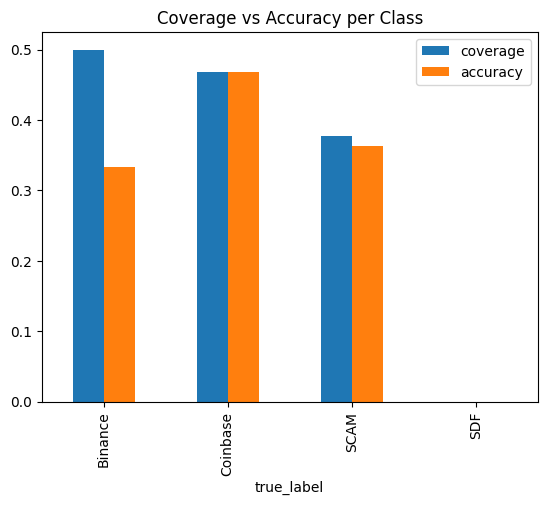

In [6]:
summary = df.groupby("true_label").agg(
    coverage=("reached", "mean"),
    accuracy=("correct", "mean")
)

summary.plot(kind="bar")
plt.title("Coverage vs Accuracy per Class")
plt.show()

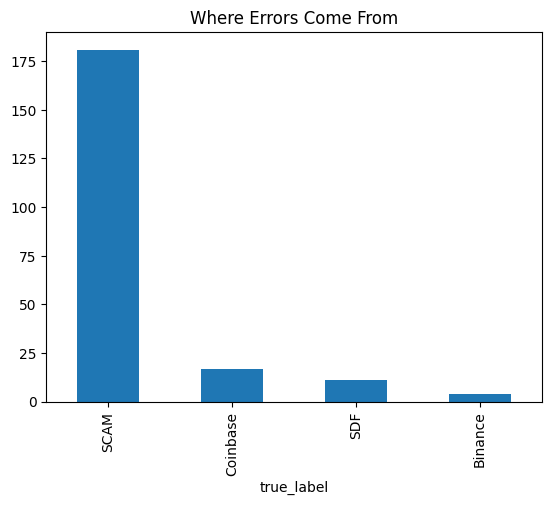

In [8]:
errors = df[df["correct"] == False]

error_counts = errors["true_label"].value_counts()

error_counts.plot(kind="bar")
plt.title("Where Errors Come From")
plt.show()

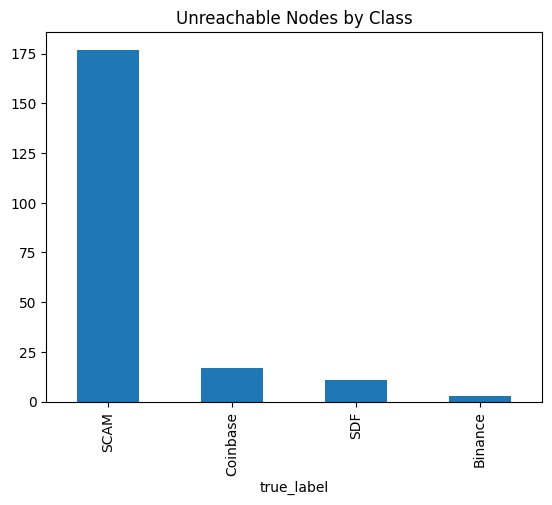

In [9]:
cluster_x = df[df["reached"] == False]

cluster_x["true_label"].value_counts().plot(kind="bar")
plt.title("Unreachable Nodes by Class")
plt.show()

3

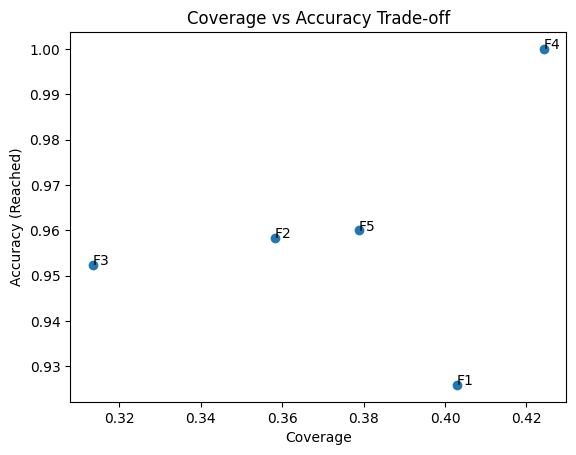

In [10]:
df = pd.read_csv("sslpa_eval_per_fold.csv")

plt.figure()
plt.scatter(df["coverage"], df["accuracy_reached"])

for i, row in df.iterrows():
    plt.text(row["coverage"], row["accuracy_reached"], f"F{int(row['fold'])}")

plt.xlabel("Coverage")
plt.ylabel("Accuracy (Reached)")
plt.title("Coverage vs Accuracy Trade-off")
plt.show()

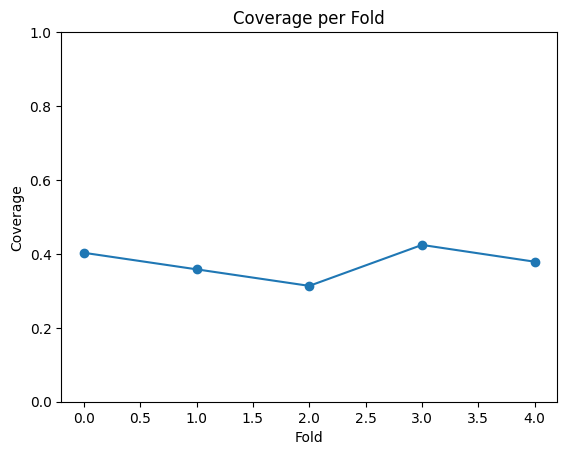

In [11]:
df["coverage"].plot(marker="o")
plt.title("Coverage per Fold")
plt.xlabel("Fold")
plt.ylabel("Coverage")
plt.ylim(0, 1)
plt.show()

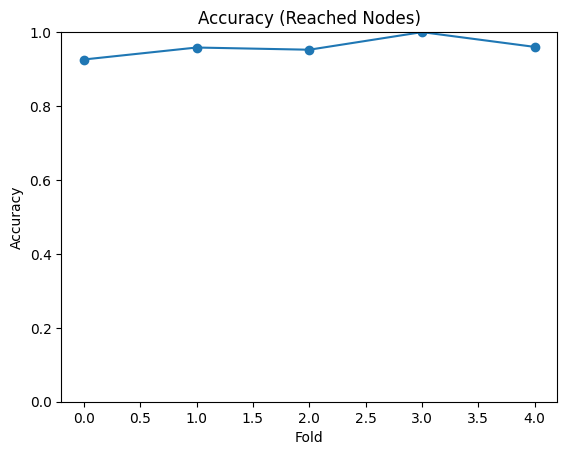

In [12]:
df["accuracy_reached"].plot(marker="o")
plt.title("Accuracy (Reached Nodes)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

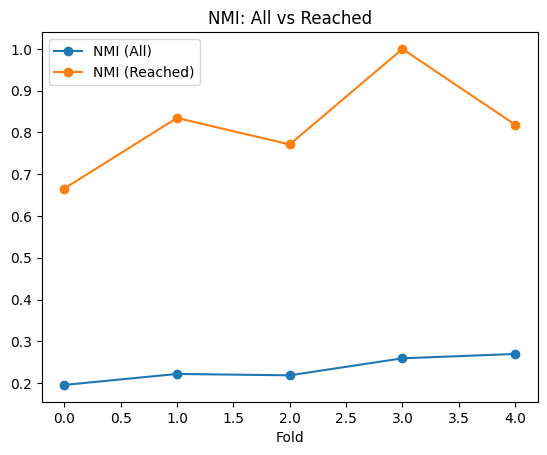

In [13]:
plt.plot(df["NMI_all"], label="NMI (All)", marker="o")
plt.plot(df["NMI_reached"], label="NMI (Reached)", marker="o")

plt.legend()
plt.title("NMI: All vs Reached")
plt.xlabel("Fold")
plt.show()

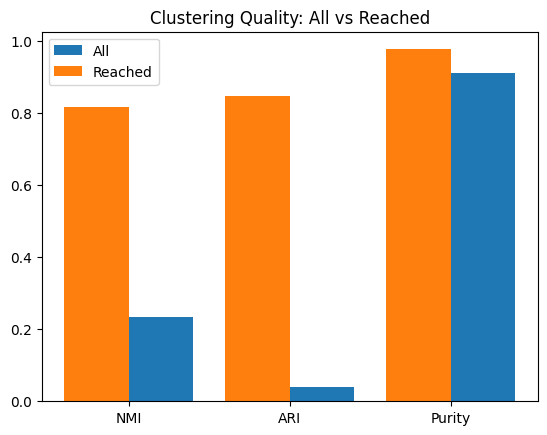

In [14]:
metrics = ["NMI", "ARI", "Purity"]

means_all = [df[f"{m}_all"].mean() for m in metrics]
means_reached = [df[f"{m}_reached"].mean() for m in metrics]

x = range(len(metrics))

plt.bar(x, means_all, width=0.4, label="All", align="edge")
plt.bar(x, means_reached, width=-0.4, label="Reached", align="edge")

plt.xticks(x, metrics)
plt.legend()
plt.title("Clustering Quality: All vs Reached")
plt.show()

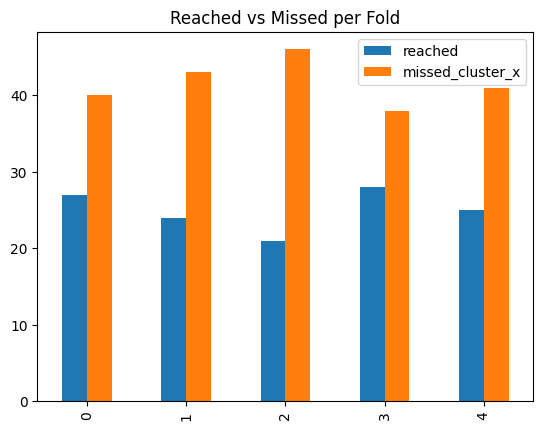

In [15]:
df[["reached", "missed_cluster_x"]].plot(kind="bar")
plt.title("Reached vs Missed per Fold")
plt.show()